# Eksperimen Klasifikasi Named Entity Recognition (NER) & Perangkuman Teks Berita Otomatis
**Tugas Akhir - Sistem Perangkuman Teks Otomatis Bahasa Indonesia**

Notebook ini memuat seluruh pipeline eksperimen penelitian mulai dari pelatihan model Named Entity Recognition (NER) berbasis arsitektur **Bidirectional LSTM (BiLSTM)** dengan deep learning TensorFlow, optimasi bobot perangkuman hibrida menggunakan **Bayesian Optimization**, hingga evaluasi performa perangkuman teks berita otomatis.

---

### Alur Utama Pipeline Eksperimen:

1. **Klasifikasi Named Entity Recognition (NER)**:
   * **Preprocessing**: Tokenisasi kalimat, penanganan format token CoNLL, pemetaan label entitas numerik, dan pengisian urutan (*padding*).
   * **Ekstraksi Fitur**: Pembuatan matriks *Word Embedding* statis menggunakan pre-trained Word2Vec (Gensim).
   * **Training & Tuning**: Pembangunan model BiLSTM TensorFlow Keras, optimasi otomatis dengan *Hyperparameter Tuning* (**Hyperband** via Keras Tuner), evaluasi real-time skor F1-Score menggunakan callback `seqeval`, serta penyimpanan bobot model terbaik.

2. **Perangkuman Teks (Summarization - Hybrid)**:
   * **Preprocessing**: Stemming kata menggunakan library `PySastrawi` dan pembuangan stopwords menggunakan library `NLTK`.
   * **Skor Kalimat**: Perhitungan 7 fitur utama (4 statistik: *Title Similarity, Location, Word Frequency, Sentence Position*; dan 3 semantik: kemunculan entitas hasil prediksi model BiLSTM-NER).
   * **Optimasi Bobot**: Pencarian kombinasi bobot fitur optimal secara otomatis menggunakan **Bayesian Optimization (Gaussian Process)** dari library `scikit-optimize` untuk memaksimalkan skor ROUGE-L pada data validasi.
   * **Inference**: Pengujian hasil ringkasan pada data uji (*test set*) dan visualisasi penandaan entitas yang terdeteksi secara interaktif.

3. **Metode Tradisional (Baseline)**:
   * Pengujian perangkuman menggunakan metode ekstraksi statistik murni (tanpa keterlibatan NER) pada dataset IndoSum sebagai pembanding dasar (*baseline*).


In [ ]:
import tensorflow as tf; print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!apt-get install graphviz -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fontconfig fontconfig-config fonts-dejavu-core fonts-liberation libann0
  libbsd0 libcairo2 libcdt5 libcgraph6 libdatrie1 libdeflate0 libfontconfig1
  libfreetype6 libfribidi0 libgd3 libgraphite2-3 libgts-0.7-5 libgts-bin
  libgvc6 libgvpr2 libharfbuzz0b libice6 libjbig0 libjpeg-turbo8 libjpeg8
  liblab-gamut1 libltdl7 libmd0 libpango-1.0-0 libpangocairo-1.0-0
  libpangoft2-1.0-0 libpathplan4 libpixman-1-0 libpng16-16 libsm6 libthai-data
  libthai0 libtiff5 libwebp7 libx11-6 libx11-data libxau6 libxaw7
  libxcb-render0 libxcb-shm0 libxcb1 libxdmcp6 libxext6 libxmu6 libxpm4
  libxrender1 libxt6 ucf x11-common
Suggested packages:
  gsfonts graphviz-doc libgd-tools
The following NEW packages will be installed:
  fontconfig fontconfig-config fonts-dejavu-core fonts-liberation graphviz
  libann0 libbsd0 libcairo2 libcdt5 libcgraph6 libdatrie

In [ ]:
!pip install keras_tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 996.3 kB/s eta 0:00:00

[notice] A new release of pip is available: 24.1.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


# NER

## Imports and Global Configuration

In [ ]:
import os
import json
import joblib
import pickle
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import chain
from datetime import datetime

import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dropout, Dense, TextVectorization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import plot_model
import keras_tuner as kt

from gensim.models import Word2Vec
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
from seqeval.metrics import f1_score as seqeval_f1
from seqeval.metrics import classification_report as seqeval_report

PAD_LABEL = "<PAD>"
PAD_INDEX = 0
RANDOM_SEED = 42

CONFIG = {
    "embed_dim": 150,
    "w2v_window": 5,
    "w2v_min_count": 1,
    "w2v_epochs": 10,
    "w2v_sg": 1, # Skip-gram
    "min_freq": 1,
    "lstm_units": 64,
    "dropout": 0.2,
    "learning_rate": 0.01,
    "trainable_embeddings": True,
    "num_lstm_layers": 2,
    "recurrent_dropout": 0.1,
    "epochs": 50,
    "batch_size": 128,
    "max_cap_len": 256,
    "patience": 10,
}

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"All libraries imported successfully (TensorFlow v{tf.__version__})")

All libraries imported successfully (TensorFlow v2.17.0)


## Custom Keras Objects & Callbacks


In [ ]:
def masked_sparse_cce(y_true, y_pred):
    loss_obj = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction='none')
    loss = loss_obj(y_true, y_pred)
    mask = tf.cast(tf.not_equal(y_true, PAD_INDEX), dtype=loss.dtype)
    loss *= mask
    return tf.reduce_sum(loss) / (tf.reduce_sum(mask) + 1e-12)

def masked_accuracy(y_true, y_pred):
    preds = tf.argmax(y_pred, axis=-1, output_type=y_true.dtype)
    matches = tf.cast(tf.equal(y_true, preds), tf.float32)
    mask = tf.cast(tf.not_equal(y_true, PAD_INDEX), tf.float32)
    return tf.reduce_sum(matches * mask) / (tf.reduce_sum(mask) + 1e-12)

class SeqevalCallback(tf.keras.callbacks.Callback):
    def __init__(self, dev_data, idx_to_tag, out_dir):
        super().__init__()
        self.X_dev, self.y_dev = dev_data
        self.idx_to_tag = idx_to_tag
        self.out_dir = out_dir
        self.save_path = os.path.join(out_dir, "best_model_by_f1.keras")
        self.best_f1 = -1.0
        self.f1_history = []

    def on_epoch_end(self, epoch, logs=None):
        preds = np.argmax(self.model.predict(self.X_dev, verbose=0, batch_size=512), axis=-1)
        true_seqs = [[self.idx_to_tag.get(i, "O") for i in seq if i != PAD_INDEX] for seq in self.y_dev]
        pred_seqs = [[self.idx_to_tag.get(i, "O") for i, m in zip(p_seq, mask) if m]
                     for p_seq, mask in zip(preds, self.y_dev != PAD_INDEX)]

        if not true_seqs: return
        f1 = seqeval_f1(true_seqs, pred_seqs)
        self.f1_history.append(f1)
        logs['val_entity_f1'] = f1
        print(f" — val_entity_f1: {f1:.4f}", end="")

        if f1 > self.best_f1:
            print(f" (New best F1, saving model to {self.save_path})")
            self.best_f1 = f1
            self.model.save(self.save_path)


## Data Loading and Preprocessing


In [ ]:
def read_data(file_path):
    sentences, labels = [], []
    current_tokens, current_labels = [], []

    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                if current_tokens:
                    sentences.append(current_tokens)
                    labels.append(current_labels)
                    current_tokens, current_labels = [], []
            else:
                parts = line.split()
                current_tokens.append(parts[0])
                current_labels.append(parts[-1])

    if current_tokens:
        sentences.append(current_tokens)
        labels.append(current_labels)

    return sentences, labels

def build_vectorizer_and_embeddings(sentences, config):
    print("Building TextVectorization and Word2Vec...")
    # vocabulary
    text_samples = [" ".join(s) for s in sentences]
    vectorizer = TextVectorization(
        max_tokens=None,
        standardize=None,
        split='whitespace',
        output_mode='int'
    )
    vectorizer.adapt(text_samples)
    voc = vectorizer.get_vocabulary() # ['', '[UNK]', 'Indo', 'adalah'...]
    vocab_size = len(voc)
    print(f"  - Vocabulary size: {vocab_size} unique tokens.")

    # Word2Vec
    w2v_model = Word2Vec(sentences=sentences, vector_size=config['embed_dim'],
                           window=config['w2v_window'], min_count=config['w2v_min_count'],
                           sg=config['w2v_sg'], epochs=config['w2v_epochs'], workers=os.cpu_count())

    # embedding matrix
    # 0 = PAD, 1 = UNK
    matrix = np.zeros((vocab_size, config['embed_dim'])).astype(np.float32)

    hits = 0
    for i, word in enumerate(voc):
        if i < 2: continue # Skip PAD & UNK
        if word in w2v_model.wv:
            matrix[i] = w2v_model.wv[word]
            hits += 1

    print(f"  - Embedding matrix created. Shape: {matrix.shape}. Word2Vec Coverage: {hits/vocab_size:.2%}")
    return vectorizer, matrix, vocab_size

def build_label_mappings(all_labels):
    unique_labels = sorted(set(chain.from_iterable(all_labels)))
    tag_to_idx = {PAD_LABEL: 0, "O": 1}
    if "O" in unique_labels: unique_labels.remove("O")

    for label in unique_labels:
        if label not in tag_to_idx:
            tag_to_idx[label] = len(tag_to_idx)

    idx_to_tag = {idx: tag for tag, idx in tag_to_idx.items()}
    print(f"Label mappings created: {len(tag_to_idx)} unique tags.")
    return tag_to_idx, idx_to_tag

def prepare_sequences(sentences, labels, vectorizer, tag_to_idx, max_len):
    text_inputs = [" ".join(s) for s in sentences]
    X_seq = vectorizer(text_inputs)
    X_np = X_seq.numpy()
    X_padded = pad_sequences(X_np, maxlen=max_len, padding="post", value=0) # 0 = PAD
    y = [[tag_to_idx.get(str(l), tag_to_idx["O"]) for l in s] for s in labels]
    y_padded = pad_sequences(y, maxlen=max_len, padding="post", value=PAD_INDEX)

    return X_padded, y_padded

## Model Building and Hyperparameter Tuning


In [ ]:
def build_model(hp, vocab_size, n_classes, max_len, embedding_matrix, base_config):
    lstm_units = hp.Choice('lstm_units', values=[64, 128, 256, 384, 512]) if hp else base_config['lstm_units']
    dropout = hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1) if hp else base_config['dropout']
    learning_rate = hp.Choice('learning_rate', values=[1e-4, 1e-3, 5e-3, 1e-2]) if hp else base_config['learning_rate']
    num_lstm_layers = hp.Int('num_lstm_layers', min_value=1, max_value=4) if hp else base_config['num_lstm_layers']
    trainable_embeddings = hp.Boolean('trainable_embeddings') if hp else base_config['trainable_embeddings']

    input_layer = Input(shape=(max_len,), name='input')
    embedding_layer = Embedding(
        input_dim=vocab_size, output_dim=base_config['embed_dim'],
        weights=[embedding_matrix], mask_zero=True,
        trainable=trainable_embeddings, name='embedding'
    )(input_layer)

    x = embedding_layer
    for i in range(num_lstm_layers):
        x = Bidirectional(LSTM(lstm_units, return_sequences=True, name=f'lstm_{i+1}'))(x)

    x = Dropout(dropout)(x)
    output_layer = Dense(n_classes, activation='softmax', name='output')(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer=Adam(learning_rate), loss=masked_sparse_cce, metrics=[masked_accuracy])
    return model

def get_model(tune_config, data, vocab_info, embedding_matrix, config, output_dir):
    (X_train, y_train, X_dev, y_dev) = data
    (vocab_size, n_classes, max_len) = vocab_info

    if tune_config and tune_config.get("enabled", False):
        print("\nStarting Hyperparameter Tuning...")
        strategy = tune_config.get("strategy", "hyperband")

        tuner = kt.Hyperband(
            lambda hp: build_model_for_tuning(hp, vocab_size, n_classes, max_len, embedding_matrix, config),
            objective='val_loss',
            max_epochs=tune_config.get("epochs", 15),
            factor=3,
            directory=output_dir,
            project_name='ner_tuning',
            overwrite=True
        )

        tuner.search(X_train, y_train, validation_data=(X_dev, y_dev),
                     callbacks=[EarlyStopping(monitor='val_loss', patience=5)])

        best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
        model = tuner.get_best_models(num_models=1)[0]

        print("\nBest Hyperparameters Found:")
        final_config = config.copy()
        for key, value in best_hps.values.items():
            print(f"  - {key}: {value}")
            final_config[key] = value

        return model, final_config
    else:
        print("\n(tuning disabled).")
        hp = kt.HyperParameters()
        hp.values.update({k: v for k,v in config.items() if k in ['lstm_units','dropout','learning_rate','num_lstm_layers','trainable_embeddings']})
        model = build_model_for_tuning(hp, vocab_size, n_classes, max_len, embedding_matrix, config)
        return model, config


## Evaluation, Visualization, and Artifact Management

In [ ]:
def evaluate_model(model, X_test, y_test, idx_to_tag, batch_size):
    print("\nEvaluating model on test data...")
    y_pred_probs = model.predict(X_test, batch_size=batch_size, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=-1)

    metrics = {}
    # --- Token-Level Evaluation (Scikit-learn) ---
    true_flat = y_test[y_test != PAD_INDEX]
    pred_flat = y_pred[y_test != PAD_INDEX]

    accuracy = accuracy_score(true_flat, pred_flat)
    f1_w = f1_score(true_flat, pred_flat, average='weighted', zero_division=0)
    f1_m = f1_score(true_flat, pred_flat, average='macro', zero_division=0)
    prec_w = precision_score(true_flat, pred_flat, average='weighted', zero_division=0)
    rec_w = recall_score(true_flat, pred_flat, average='weighted', zero_division=0)

    print("\nToken-level Metrics:")
    print(f"Accuracy: {accuracy:.4f}, F1_weighted: {f1_w:.4f}, F1_macro: {f1_m:.4f}")

    metrics.update({
        "accuracy": accuracy,
        "f1_weighted": f1_w,
        "f1_macro": f1_m,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w
    })

    # --- Entity-Level Evaluation (Seqeval) ---
    true_seqs = [[idx_to_tag.get(i, "O") for i in seq if i != PAD_INDEX] for seq in y_test]
    pred_seqs = [[idx_to_tag.get(i, "O") for i, m in zip(p_seq, mask) if m]
                 for p_seq, mask in zip(y_pred, y_test != PAD_INDEX)]

    if true_seqs:
        report = seqeval_report(true_seqs, pred_seqs, digits=4)
        f1 = seqeval_f1(true_seqs, pred_seqs)
        print("\n📋 Entity-level Classification Report (Test Set):")
        print(report)
        metrics.update({
            "entity_f1": f1,
            "entity_report": report
        })
    else:
        print("No valid sequences to evaluate.")

    # --- Classification Report ---
    labels_sorted = sorted([k for k in idx_to_tag.keys() if k != PAD_INDEX])
    target_names = [idx_to_tag[i] for i in labels_sorted]

    report = classification_report(
        true_flat,
        pred_flat,
        labels=labels_sorted,
        target_names=target_names,
        zero_division=0,
        digits=4
    )
    print("\nToken-level Classification Report:\n", report)
    metrics["classification_report"] = report

    return metrics

def plot_training_history(history, f1_history, output_dir):
    print("\nGenerating plots...")
    epochs = range(1, len(history.history['loss']) + 1)

    # --- PLOT 1: Training Metrics (Loss & Accuracy) ---
    fig1, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig1.suptitle('Model Training Metrics', fontsize=16, fontweight='bold')

    axes[0].plot(epochs, history.history['loss'], 'bo-', label='Training Loss')
    axes[0].plot(epochs, history.history['val_loss'], 'ro-', label='Validation Loss')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history.history['masked_accuracy'], 'go-', label='Training Accuracy')
    axes[1].plot(epochs, history.history['val_masked_accuracy'], 'mo-', label='Validation Accuracy')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    path1 = os.path.join(output_dir, "training_metrics.png")
    plt.savefig(path1, dpi=300)
    plt.close(fig1)
    print(f"  - Saved: {path1}")

    # --- PLOT 2: Entity F1 Score ---
    if f1_history:
        fig2, ax = plt.subplots(figsize=(10, 6))
        f1_epochs = range(1, len(f1_history) + 1)
        ax.plot(f1_epochs, f1_history, 'yo-', marker='o', linestyle='-', linewidth=2, label='Val Entity F1')

        best_f1 = max(f1_history)
        best_epoch = f1_history.index(best_f1) + 1
        ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.7)
        ax.text(best_epoch, best_f1, f'Best: {best_f1:.3f}',
                       bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))
        ax.plot(best_epoch, best_f1, 'r*', markersize=15, label=f'Best: {best_f1:.4f}')

        ax.set_title('Entity F1 Score', fontsize=14)
        ax.set_xlabel('Epoch'); ax.set_ylabel('F1 Score')
        ax.legend(); ax.grid(True, alpha=0.3)

        path2 = os.path.join(output_dir, "entity_f1_metrics.png")
        plt.savefig(path2, dpi=300)
        plt.close(fig2)
        print(f"  - Saved: {path2}")


def save_artifacts(output_dir, model, config, vectorizer, tag_to_idx, embedding_matrix, metrics):
    print(f"\nSaving all artifacts to {output_dir}...")
    os.makedirs(output_dir, exist_ok=True)

    model.save(os.path.join(output_dir, "model.keras"))
    vec_data = {
        'config': vectorizer.get_config(),
        'vocabulary': vectorizer.get_vocabulary()
    }
    pickle.dump(vec_data,
            open(os.path.join(output_dir, "vectorizer.pkl"), "wb"))
    joblib.dump(tag_to_idx, os.path.join(output_dir, "tag_to_idx.pkl"))
    np.save(os.path.join(output_dir, "embedding_matrix.npy"), embedding_matrix)

    results = {
        "config": config,
        "metrics": {k: v for k, v in metrics.items() if k not in ["classification_report", "entity_report"]},
        "vocab_size": len(vectorizer.get_vocabulary()),
        "num_classes": len(tag_to_idx),
        "timestamp": datetime.now().isoformat()
    }

    with open(os.path.join(output_dir, "experiment_results.json"), 'w') as f:
        json.dump(results, f, indent=2)

    if "classification_report" in test_metrics:
        with open(os.path.join(output_dir, "classification_report.txt"), "w", encoding="utf-8") as f:
            f.write(test_metrics["classification_report"])

    if "entity_report" in test_metrics:
        with open(os.path.join(output_dir, "entity_report.txt"), "w", encoding="utf-8") as f:
            f.write(test_metrics["entity_report"])


    try:
        plot_model(model, to_file=os.path.join(output_dir, "model_architecture.png"), show_shapes=True)
    except Exception as e:
        print(f"\nCould not save model plot, Error: {e}")

    print("All artifacts saved successfully.")


def load_artifacts(model_dir):
    print(f"Loading all artifacts from: {model_dir}")

    model_path = os.path.join(model_dir, "best_model_by_f1.keras")
    if not os.path.exists(model_path):
        model_path = os.path.join(model_dir, "model.keras")

    model = load_model(
        model_path,
        custom_objects={'masked_sparse_cce': masked_sparse_cce, 'masked_accuracy': masked_accuracy}
    )

    vect_data = pickle.load(open(os.path.join(model_dir, "vectorizer.pkl"), "rb"))
    vectorizer = TextVectorization.from_config(vect_data['config'])
    vectorizer.set_vocabulary(vect_data['vocabulary'])

    tag_to_idx = joblib.load(os.path.join(model_dir, "tag_to_idx.pkl"))
    idx_to_tag = {idx: tag for tag, idx in tag_to_idx.items()}

    with open(os.path.join(model_dir, "experiment_results.json")) as f:
        config = json.load(f)['config']
        max_len = config['max_cap_len']

    print("Artifacts loaded successfully.")
    return model, vectorizer, idx_to_tag, max_len

## Prediction


In [ ]:
def clean_and_space_punctuation(text):
    import re
    """
    1. "(LSI)"        -> "(LSI)"
    2. "21%"          -> "21%"
    3. "non-kader"    -> "non-kader"
    4. "22.61"        -> "22.61"
    5. "Haposan,"     -> "Haposan ,"
    6. "terjadi."     -> "terjadi ."
    7. "(Situbondo)," -> "(Situbondo) ,"
    """
    # whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # (Koma, Titik, Titik Dua, Titik Koma)
    #    HANYA JIKA berada di AKHIR kata (diikuti spasi atau akhir string).
    #    Regex: (?<=\S)  = Lookbehind: Sebelumnya harus ada karakter (bukan spasi)
    #           ([,.:;?!]) = Group 1: Tanda baca target
    #           (?=\s|$) = Lookahead: Setelahnya harus spasi atau akhir kalimat
    #
    #    Ini menjaga "22.61" (karena setelah titik adalah angka '6', bukan spasi)
    #    Ini menjaga "Haposan," (karena setelah koma adalah spasi/akhir)
    text = re.sub(r'(?<=\S)([,.:;?!])(?=\s|$)', r' \1', text)
    return text

def extract_entities(tokens, tags, confidences):
    entities, current_entity = [], None
    for i, (token, tag, conf) in enumerate(zip(tokens, tags, confidences)):
        if tag.startswith("B-"):
            if current_entity:
                current_entity['confidence'] = np.mean(current_entity['conf_scores'])
                del current_entity['conf_scores']
                entities.append(current_entity)
            current_entity = {
                "label": tag[2:],
                "text": token,
                "conf_scores": [conf]
            }
        elif tag.startswith("I-") and current_entity and tag[2:] == current_entity["label"]:
            current_entity["text"] += " " + token
            current_entity["conf_scores"].append(conf)
        else:
            if current_entity:
                current_entity['confidence'] = np.mean(current_entity['conf_scores'])
                del current_entity['conf_scores']
                entities.append(current_entity)
            current_entity = None
    if current_entity:
        current_entity['confidence'] = np.mean(current_entity['conf_scores'])
        del current_entity['conf_scores']
        entities.append(current_entity)

    return entities

def predict_on_sentences(sentences, model, vectorizer, idx_to_tag, max_len):
    if isinstance(sentences, str): sentences = [sentences]

    print(sentences)
    # tokenize
    tokenized_sents = [clean_and_space_punctuation(s).split() for s in sentences]
    print(tokenized_sents)

    # vectorize
    text_inputs = [" ".join(s) for s in tokenized_sents]
    X_seq = vectorizer(text_inputs).numpy()

    # padding
    X_padded = pad_sequences(X_seq, maxlen=max_len, padding="post", value=0)
    print(X_padded)

    # predict
    preds_probs = model.predict(X_padded, verbose=0, batch_size=256)
    pred_ids = np.argmax(preds_probs, axis=-1)
    confidences = np.max(preds_probs, axis=-1)

    all_results = []
    for i, (tokens, ids, confs, original_sent) in enumerate(zip(tokenized_sents, pred_ids, confidences, sentences)):
        num_tokens = len(tokens)
        tags = [idx_to_tag.get(pid, "O") for pid in ids[:num_tokens]]
        token_confidences = confs[:num_tokens]

        entities = extract_entities(tokens, tags, token_confidences)

        print("\n" + "-"*50)
        print(f"Sentence {i+1}: \"{original_sent}\"")
        if entities:
            print("  Entities Found:")
            for ent in entities:
                print(f"    - {ent['text']} ({ent['label']}, {ent['confidence']:.2%})")
        else:
            print("  No entities found.")
        print("-" * 50)

        all_results.append({'sentence': original_sent, 'entities': entities})

    return all_results


## Main Execution Pipeline


In [ ]:
# --- 1. Configuration ---
import locale
from datetime import datetime
locale.setlocale(locale.LC_TIME, '')
timestamp = datetime.now().strftime('%d-%B-%Y_%H.%M')
OUTPUT_DIR = f"results/ner_experiment_{timestamp}"
TRAIN_PATH = "ner2/train.txt"
DEV_PATH = "ner2/dev.txt"
TEST_PATH = "ner2/test.txt"
DATA_FORMAT = "conll"

# Set 'enabled' to False to skip and use default CONFIG.
TUNE_HYPERPARAMETERS = False

# --- 2. Load and Prepare Data ---
print("="*60)
print("")
print("="*60)
os.makedirs(OUTPUT_DIR, exist_ok=True)
train_sents, train_labels = read_data(TRAIN_PATH, DATA_FORMAT)
dev_sents, dev_labels = read_data(DEV_PATH, DATA_FORMAT)
test_sents, test_labels = read_data(TEST_PATH, DATA_FORMAT)
print(f"Data loaded: {len(train_sents)} train, {len(dev_sents)} dev, {len(test_sents)} test sentences.")

# --- 3. Build Vocabularies and Embeddings ---
vectorizer, embedding_matrix, vocab_size = build_vectorizer_and_embeddings(train_sents, CONFIG)
tag_to_idx, idx_to_tag = build_label_mappings(train_labels + dev_labels + test_labels)
n_classes = len(tag_to_idx)
max_len = CONFIG['max_cap_len']

# --- 4. Prepare Padded Sequences ---
X_train, y_train = prepare_sequences(train_sents, train_labels, vectorizer, tag_to_idx, max_len)
X_dev, y_dev = prepare_sequences(dev_sents, dev_labels, vectorizer, tag_to_idx, max_len)
X_test, y_test = prepare_sequences(test_sents, test_labels, vectorizer, tag_to_idx, max_len)
print("All sequences prepared and padded.")

# --- 5. Get Model ---
final_config = CONFIG.copy()
if TUNE_HYPERPARAMETERS:
    print("\nStarting Hyperparameter Tuning...")
    tuner = kt.Hyperband(
        lambda hp: build_model(hp, vocab_size, n_classes, max_len, embedding_matrix, CONFIG),
        objective='val_loss', max_epochs=15, factor=3,
        directory=OUTPUT_DIR, project_name='ner_tuning', overwrite=True
    )
    tuner.search(X_train, y_train, validation_data=(X_dev, y_dev), callbacks=[EarlyStopping(patience=5)])

    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
    model = tuner.get_best_models(num_models=1)[0]
    print("\nBest Hyperparameters Found:")
    for key, value in best_hps.values.items():
        print(f"  - {key}: {value}")
        final_config[key] = value
else:
    print("\nBuilding model with default configuration (tuning disabled).")
    model = build_model(None, vocab_size, n_classes, max_len, embedding_matrix, CONFIG)

model.summary()

# --- 6. Final Model Training ---
print("\nStarting final model training...")
seq_eval_cb = SeqevalCallback(dev_data=(X_dev, y_dev), idx_to_tag=idx_to_tag, out_dir=OUTPUT_DIR)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=final_config['patience'], restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    seq_eval_cb
]
history = model.fit(
    X_train, y_train,
    validation_data=(X_dev, y_dev),
    batch_size=final_config['batch_size'],
    epochs=final_config['epochs'],
    callbacks=callbacks,
    verbose=1
)

# --- 7. Evaluation and Reporting ---
best_model_path = seq_eval_cb.save_path
if os.path.exists(best_model_path):
    print(f"\nLoading best model from: {best_model_path}")
    final_model = load_model(best_model_path, custom_objects={'masked_sparse_cce': masked_sparse_cce, 'masked_accuracy': masked_accuracy})
else:
    print("\nUsing final model from training (no best model was saved).")
    final_model = model

test_metrics = evaluate_model(final_model, X_test, y_test, idx_to_tag, final_config['batch_size'])
plot_training_history(history, seq_eval_cb.f1_history, OUTPUT_DIR)
save_artifacts(OUTPUT_DIR, final_model, final_config, vectorizer, tag_to_idx, embedding_matrix, test_metrics)
print(f"All artifacts are saved in: {OUTPUT_DIR}")

print("\n\n" + "="*60)
print("")
print("="*60)



Data loaded: 1464 train, 367 dev, 509 test sentences.
Building TextVectorization and Word2Vec...


I0000 00:00:1767698847.635513      12 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1767698847.705921      12 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1767698847.705979      12 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1767698847.708201      12 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1767698847.708243      12 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

  - Vocabulary size: 6631 unique tokens.
  - Embedding matrix created. Shape: (6631, 150). Word2Vec Coverage: 99.97%
Label mappings created: 8 unique tags.
All sequences prepared and padded.

Building model with default configuration (tuning disabled).


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 256)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 256, 150)  │    994,650 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 256)       │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 256, 128)  │    110,080 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 256, 128)  │     98,816 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256, 128)  │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 256, 8)    │      1,032 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

...

 Trainable params: 1,204,578 (4.60 MB)

 Non-trainable params: 0 (0.00 B)


Starting final model training...
Epoch 1/50


2026-01-06 11:27:32.845917: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906


11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 1.0927 - masked_accuracy: 0.6515 — val_entity_f1: 0.0000 (New best F1, saving model to results/ner_experiment_06-January-2026_11.27/best_model_by_f1.keras)
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 161ms/step - loss: 1.0455 - masked_accuracy: 0.6765 - val_loss: 0.5872 - val_masked_accuracy: 0.8842 - learning_rate: 0.0100 - val_entity_f1: 0.0000e+00
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 0.5795 - masked_accuracy: 0.8814 - val_loss: 0.4433 - val_masked_accuracy: 0.8842 - learning_rate: 0.0100 - val_entity_f1: 0.0000e+00
Epoch 3/50
11/12 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.3855 - masked_accuracy: 0.8832 — val_entity_f1: 0.2226 (New best F1, saving model to results/ner_experiment_06-January-2026_11.27/best_model_by_f1.keras)
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.3766 - masked_accuracy: 0.8846 - val_loss: 0.3421 - val_masked_accuracy: 0.9011 - learning_rate: 0.0100 - val_entity_f1: 0.2226
Epoch 4/50
11/12 ━━━━━━━━━━

## Inference Example


In [ ]:
def evaluate_model(model, X_test, y_test, idx_to_tag, batch_size):
    print("\nEvaluating model on test data...")
    y_pred_probs = model.predict(X_test, batch_size=batch_size, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=-1)

    metrics = {}
    # --- Token-Level Evaluation (Scikit-learn) ---
    true_flat = y_test[y_test != PAD_INDEX]
    pred_flat = y_pred[y_test != PAD_INDEX]

    accuracy = accuracy_score(true_flat, pred_flat)
    f1_w = f1_score(true_flat, pred_flat, average='weighted', zero_division=0)
    f1_m = f1_score(true_flat, pred_flat, average='macro', zero_division=0)
    prec_w = precision_score(true_flat, pred_flat, average='weighted', zero_division=0)
    rec_w = recall_score(true_flat, pred_flat, average='weighted', zero_division=0)

    print("\nToken-level Metrics:")
    print(f"Accuracy: {accuracy:.4f}, F1_weighted: {f1_w:.4f}, F1_macro: {f1_m:.4f}")

    metrics.update({
        "accuracy": accuracy,
        "f1_weighted": f1_w,
        "f1_macro": f1_m,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w
    })

    # --- Entity-Level Evaluation (Seqeval) ---
    true_seqs = [[idx_to_tag.get(i, "O") for i in seq if i != PAD_INDEX] for seq in y_test]
    pred_seqs = [[idx_to_tag.get(i, "O") for i, m in zip(p_seq, mask) if m]
                 for p_seq, mask in zip(y_pred, y_test != PAD_INDEX)]

    if true_seqs:
        report = seqeval_report(true_seqs, pred_seqs, digits=4)
        f1 = seqeval_f1(true_seqs, pred_seqs)
        print("\n📋 Entity-level Classification Report (Test Set):")
        print(report)
        metrics.update({
            "entity_f1": f1,
            "entity_report": report
        })
    else:
        print("No valid sequences to evaluate.")

    # --- Classification Report ---
    labels_sorted = sorted([k for k in idx_to_tag.keys() if k != PAD_INDEX])
    target_names = [idx_to_tag[i] for i in labels_sorted]

    report = classification_report(
        true_flat,
        pred_flat,
        labels=labels_sorted,
        target_names=target_names,
        zero_division=0,
        digits=4
    )
    print("\nToken-level Classification Report:\n", report)
    metrics["classification_report"] = report

    plot_confusion_matrix(true_flat, pred_flat, target_names, output_dir)

    return metrics

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(true_flat, pred_flat, target_names, output_dir):
    print("Generating Confusion Matrix...")
    cm = confusion_matrix(true_flat, pred_flat)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=target_names,
                yticklabels=target_names, cmap='Blues')
    plt.title('Token-Level Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('True')

    if output_dir:
        path = os.path.join(output_dir, "confusion_matrix.png")
        plt.savefig(path, dpi=300, bbox_inches='tight')
        print(f"  - Saved: {path}")
    plt.show()

Loading all artifacts from: results/ner_experiment_30-November-2025_13.35
Artifacts loaded successfully.

Data loaded: 1464 train, 367 dev, 509 test sentences.
Building TextVectorization and Word2Vec...
  - Vocabulary size: 6631 unique tokens.
  - Embedding matrix created. Shape: (6631, 150). Word2Vec Coverage: 99.97%
Label mappings created: 8 unique tags.

Evaluating model on test data...
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step

Token-level Metrics:
Accuracy: 0.9332, F1_weighted: 0.9312, F1_macro: 0.7379

📋 Entity-level Classification Report (Test Set):
              precision    recall  f1-score   support

         LOC     0.4810    0.7379    0.5824       103
         ORG     0.7174    0.7282    0.7228       401
         PER     0.6725    0.5184    0.5855       515

   micro avg     0.6601    0.6232    0.6411      1019
   macro avg     0.6237    0.6615    0.6302      1019
weighted avg     0.6709    0.6232    0.6392      1019


Token-level Classification Report:
               precision

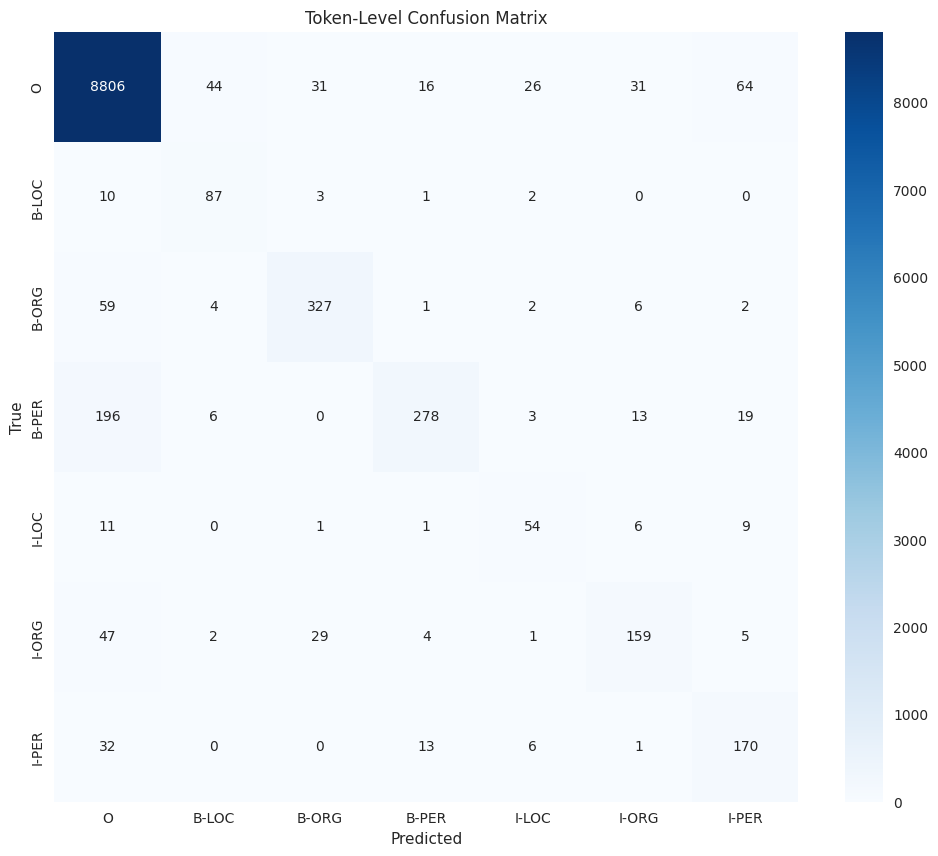


Evaluation Complete.


In [ ]:
MODEL_DIR = "results/ner_experiment_30-November-2025_13.35"
model, vectorizer, idx_to_tag, max_len = load_artifacts(MODEL_DIR)
OUTPUT_DIR = f"results/ner_experiment_30-November-2025_13.35"
TRAIN_PATH = "ner2/train.txt"
DEV_PATH = "ner2/dev.txt"
TEST_PATH = "ner2/test.txt"
DATA_FORMAT = "conll"
print("="*60)
print("")
print("="*60)
train_sents, train_labels = read_data(TRAIN_PATH)
dev_sents, dev_labels = read_data(DEV_PATH)
test_sents, test_labels = read_data(TEST_PATH)
print(f"Data loaded: {len(train_sents)} train, {len(dev_sents)} dev, {len(test_sents)} test sentences.")


vectorizer, embedding_matrix, vocab_size = build_vectorizer_and_embeddings(train_sents, CONFIG)
tag_to_idx, idx_to_tag = build_label_mappings(train_labels + dev_labels + test_labels)
n_classes = len(tag_to_idx)
max_len = CONFIG['max_cap_len']

X_train, y_train = prepare_sequences(train_sents, train_labels, vectorizer, tag_to_idx, max_len)
X_dev, y_dev = prepare_sequences(dev_sents, dev_labels, vectorizer, tag_to_idx, max_len)
X_test, y_test = prepare_sequences(test_sents, test_labels, vectorizer, tag_to_idx, max_len)


test_metrics = evaluate_model(
    model=model,
    X_test=X_test,
    y_test=y_test,
    idx_to_tag=idx_to_tag,
    batch_size=128,
    output_dir=MODEL_DIR
)

print("\nEvaluation Complete.")

# SUMMARIZATION

In [ ]:
!pip install scikit-optimize


[notice] A new release of pip is available: 24.1.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [ ]:
!pip install rouge_score


[notice] A new release of pip is available: 24.1.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [ ]:
!pip install nltk


[notice] A new release of pip is available: 24.1.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip


In [ ]:
import nltk
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## Imports and Global Configuration


In [ ]:
import os
import json
import joblib
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import nltk
from tqdm.auto import tqdm
from datetime import datetime
import functools

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from rouge_score import rouge_scorer
from seqeval.metrics import f1_score as seqeval_f1
from seqeval.metrics import classification_report as seqeval_report
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import KFold
import skopt
from skopt import gp_minimize
from skopt.space import Real
from skopt.utils import use_named_args


warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)


FEATURE_NAMES = ['title', 'location', 'frequency', 'aggregation',
                 'entity_count', 'entity_density']

DEFAULT_SUMMARY_WEIGHTS = {
    'title': 0.1,
    'location': 0.1,
    'frequency': 0.1,
    'aggregation': 0.1,
    'entity_count': 0.1,
    'entity_density': 0.1,
}
if set(DEFAULT_SUMMARY_WEIGHTS.keys()) != set(FEATURE_NAMES):
    print("Warning: DEFAULT_SUMMARY_WEIGHTS keys mismatch. Using equal defaults.")
    DEFAULT_SUMMARY_WEIGHTS = {name: 1.0/len(FEATURE_NAMES) for name in FEATURE_NAMES}

DEFAULT_COMPRESSION_RATIO = 0.3
DEFAULT_LAMBDA_MMR = 0.7


## Data Loading and Text Processing


In [ ]:
def load_indosum_jsonl(file_path):
    try:
        return pd.read_json(file_path, lines=True)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return pd.DataFrame()

def tokens_to_text(token_lists):
    """[['Suara.com', '-', 'Banjir'], [',', 'menyisakan']] -> "Suara.com - Banjir , menyisakan"""
    if not isinstance(token_lists, list): return ""
    return " ".join([" ".join(map(str, sentence)) for sentence in token_lists])

def text_to_sentences(full_text):
    if not isinstance(full_text, str): return []
    try:
        return nltk.tokenize.sent_tokenize(full_text)
    except Exception as e:
        print(f"Warning: NLTK sentence tokenization failed: {e}. Returning empty list.")
        return []

def preprocess_text_for_tfidf(sentences, stemmer, stopword_remover):
    processed_sents = []
    for sent in sentences:
        stemmed = stemmer.stem(sent)
        stopwords_removed = stopword_remover.remove(stemmed)
        processed_sents.append(stopwords_removed)
    return processed_sents


## Summarization Scoring


In [ ]:
# %% [code]
def calculate_sentence_scores(sentences, title, ner_results, tfidf_vectorizer, tfidf_matrix):
    n_sentences = len(sentences)
    if n_sentences == 0: return pd.DataFrame(columns=['sentence'] + FEATURE_NAMES)

    # Title TF-IDF
    processed_title = preprocess_text_for_tfidf([title], stemmer_global, stopword_remover_global)[0]
    title_tfidf = tfidf_vectorizer.transform([processed_title])
    title_scores = cosine_similarity(tfidf_matrix, title_tfidf).flatten()

    # Location
    location_scores = np.array([((n_sentences - i) / n_sentences) for i in range(n_sentences)])

    # Frequency
    if tfidf_matrix.shape[1] > 0:
        frequency_scores = np.asarray(tfidf_matrix.sum(axis=1)).ravel()
    else:
        frequency_scores = np.zeros(n_sentences)

    # Aggregation
    aggregation_scores = np.zeros(n_sentences)
    if n_sentences > 1 and tfidf_matrix.shape[1] > 0:
        similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
        np.fill_diagonal(similarity_matrix, 0)
        aggregation_scores = similarity_matrix.sum(axis=1)

    # --- NER Scores ---
    entity_counts = []
    entity_densities = []
    for i in range(n_sentences):
          if i < len(ner_results):
              sentence_ner_info = ner_results[i]
              sentence_entities = sentence_ner_info.get('entities', [])

              tokens = sentence_ner_info.get('tokens', sentences[i].split())
              num_tokens = len(tokens)

              current_sent_entities_set = {e['text'].lower() for e in sentence_entities}

              # Feature 1: Entity Count
              entity_counts.append(len(sentence_entities))

              # Feature 2: Entity Density
              entity_densities.append(len(sentence_entities) / num_tokens if num_tokens > 0 else 0)

          else:
              entity_counts.append(0)
              entity_densities.append(0.0)

    scores_df = pd.DataFrame({
        'sentence': sentences,
        'title': title_scores,
        'location': location_scores,
        'frequency': frequency_scores,
        'aggregation': aggregation_scores,
        'entity_count': entity_counts,
        'entity_density': entity_densities,
    })

    # Normalize [0, 1]
    for col in FEATURE_NAMES:
        if col in scores_df.columns:
            min_val, max_val = scores_df[col].min(), scores_df[col].max()
            if max_val > min_val:
                scores_df[col] = (scores_df[col] - min_val) / (max_val - min_val)
            elif max_val == min_val and max_val != 0:
                 scores_df[col] = 1.0
            else:
                scores_df[col] = 0.0

    return scores_df


## Summarization and Evaluation


In [ ]:
# %% [code]
def generate_summary(scores_df, weights, compression_ratio, lambda_mmr=DEFAULT_LAMBDA_MMR, tfidf_matrix=None, sentences=None):
    if scores_df.empty or sentences is None: return ""

    # 1. Calculate Weighted Score
    scores_df['final_score'] = 0.0
    for feature in FEATURE_NAMES:
        if feature in weights and feature in scores_df.columns:
             scores_df['final_score'] += scores_df[feature] * weights.get(feature, 0)

    n_sentences = len(scores_df)
    n_summary_sents = max(1, int(n_sentences * compression_ratio))

    # 2. Select Sentences (MMR or Top-N)
    summary_indices = []

    # MMR Logic requires TF-IDF Matrix
    if tfidf_matrix is not None and tfidf_matrix.shape[1] > 0:
        sim_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
        sentence_scores = scores_df['final_score'].values
        available_indices = list(range(n_sentences))

        # Pick first sentence (highest score)
        best_idx = np.argmax(sentence_scores)
        summary_indices.append(best_idx)
        available_indices.remove(best_idx)

        # Pick remaining using MMR
        while len(summary_indices) < n_summary_sents and available_indices:
            mmr_scores = []
            for idx in available_indices:
                # Relevance (Score) vs Diversity (Similarity to selected)
                sim_to_selected = np.max(sim_matrix[idx, summary_indices])
                mmr = lambda_mmr * sentence_scores[idx] - (1 - lambda_mmr) * sim_to_selected
                mmr_scores.append(mmr)

            best_mmr_idx = available_indices[np.argmax(mmr_scores)]
            summary_indices.append(best_mmr_idx)
            available_indices.remove(best_mmr_idx)
    else:
        summary_indices = scores_df.nlargest(n_summary_sents, 'final_score').index.tolist()

    # 3. Sort by original order
    summary_indices.sort()
    summary = " ".join([sentences[i] for i in summary_indices])
    return summary


def evaluate_summary(generated_summary, gold_summary, tfidf_vectorizer):
    """Evaluates summary (Cosine & ROUGE)."""
    cosine_sim = 0.0
    # Cosine Sim
    if generated_summary and gold_summary and hasattr(tfidf_vectorizer, 'vocabulary_'):
        try:
            vecs = tfidf_vectorizer.transform([generated_summary, gold_summary])
            cosine_sim = cosine_similarity(vecs[0], vecs[1])[0][0]
        except: pass

    # ROUGE
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    try:
        scores = scorer.score(str(gold_summary), str(generated_summary))
        r1 = scores['rouge1'].fmeasure
        r2 = scores['rouge2'].fmeasure
        rl = scores['rougeL'].fmeasure
    except:
        r1, r2, rl = 0.0, 0.0, 0.0

    return {'cosine_similarity': cosine_sim, 'rouge1_f1': r1, 'rouge2_f1': r2, 'rougeL_f1': rl}

def report_and_save_results(df_results, output_dir, file_prefix=""):
    if df_results.empty: return

    avgs = df_results.mean(numeric_only=True)
    report_str = (
        f"============================================================\n"
        f"{file_prefix.upper()} RESULTS (Docs: {len(df_results)})\n"
        f"------------------------------------------------------------\n"
        f"Avg Cosine: {avgs.get('cosine_similarity', 0):.4f}\n"
        f"ROUGE-1 F1: {avgs.get('rouge1_f1', 0):.4f}\n"
        f"ROUGE-2 F1: {avgs.get('rouge2_f1', 0):.4f}\n"
        f"ROUGE-L F1: {avgs.get('rougeL_f1', 0):.4f}\n"
        f"============================================================\n"
    )
    print(report_str)

    os.makedirs(output_dir, exist_ok=True)
    with open(os.path.join(output_dir, f"{file_prefix}_summary.txt"), 'w') as f: f.write(report_str)
    df_results.to_csv(os.path.join(output_dir, f"{file_prefix}_detailed.csv"), index=False)


## Weight Optimization


In [ ]:
iteration_counter = 0

def extract_tf_query(tfidf_matrix, vectorizer, top_n=10):
    """Fungsi pembantu untuk mengekstrak TF-based query"""
    if tfidf_matrix.shape[0] == 0:
        return ""
    # Menghitung jumlah bobot TF-IDF untuk setiap kata di seluruh kalimat dokumen
    sum_scores = np.asarray(tfidf_matrix.sum(axis=0)).ravel()
    top_indices = sum_scores.argsort()[::-1][:top_n]
    features = vectorizer.get_feature_names_out()
    return " ".join([features[i] for i in top_indices if i < len(features)])

@use_named_args(dimensions=dimensions)
def objective_function(**weights_dict):
    global iteration_counter
    iteration_counter += 1

    # 1. Normalization (Total = 1.0)
    total = sum(weights_dict.values())
    if total <= 1e-6: return 0.0
    weights = {k: v / total for k, v in weights_dict.items()}

    scores = []

    # 2. Shuffle/Sample Data
    sample_df = df_dev_global.sample(n=min(3000, len(df_dev_global)), random_state=iteration_counter)

    # 3. Iteration with tqdm
    pbar = tqdm(
        sample_df.iterrows(),
        total=len(sample_df),
        desc=f"Optimization Call #{iteration_counter}",
        leave=False
    )

    for index, row in pbar:
        try:
            gold_summary = tokens_to_text(row['summary'])

            # AMBIL DATA DOKUMEN
            current_doc = doc_data[index]
            sentences = current_doc['sents']
            proc_sents = current_doc['proc_sents']

            if not sentences:
                continue

            # PREPARASI TF-IDF MATRIX
            valid_sents = [s for s in proc_sents if s]
            if valid_sents:
                mat = tfidf_vectorizer_global.transform(valid_sents)
                tfidf_matrix = np.zeros((len(sentences), mat.shape[1]))
                orig_idx = [k for k, s in enumerate(proc_sents) if s]
                tfidf_matrix[orig_idx, :] = mat.toarray()

                # --- PERUBAHAN DI SINI ---
                # Mengganti title lama dengan TF-based query dari matriks dokumen saat ini
                tf_query = extract_tf_query(mat, tfidf_vectorizer_global)
            else:
                tfidf_matrix = np.zeros((len(sentences), len(tfidf_vectorizer_global.vocabulary_)))
                tf_query = "" # Jika dokumen kosong

            # B. Get Features (NER)
            ner_results = global_precomputed_ner_results[index]

            # C. Calculate Scores
            # Variabel 'title' diganti dengan 'tf_query'
            scores_df = calculate_sentence_scores(
                sentences, tf_query, ner_results,
                tfidf_vectorizer_global, tfidf_matrix
            )

            # D. Generate Summary
            generated_summ = generate_summary(
                scores_df, weights, COMPRESSION_RATIO,
                DEFAULT_LAMBDA_MMR, tfidf_matrix, sentences
            )

            # E. Evaluate
            metrics = evaluate_summary(generated_summ, gold_summary, tfidf_vectorizer_global)
            composite_score = (0.4 * metrics['rouge1_f1']) + (0.4 * metrics['rouge2_f1']) + (0.2 * metrics['rougeL_f1'])
            scores.append(composite_score)

        except Exception as e:
            print(f"Error at index {index}: {e}")
            scores.append(0.0)

    # 4. Return Negative Mean ROUGE
    mean_rouge = np.mean(scores) if scores else 0.0
    print(f"Call #{iteration_counter} Completed | ROUGE-L: {mean_rouge:.4f} | Weights: {list(weights.values())}")

    return -mean_rouge

## Main Execution Pipeline

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm
from datetime import datetime

def predict_on_sentences(sentences, model, vectorizer, idx_to_tag, max_len, logger=None):
    if isinstance(sentences, str): sentences = [sentences]

    # tokenize
    tokenized_sents = [clean_and_space_punctuation(s).split() for s in sentences]

    # vectorize
    text_inputs = [" ".join(s) for s in tokenized_sents]
    X_seq = vectorizer(text_inputs).numpy()

    # padding
    X_padded = pad_sequences(X_seq, maxlen=max_len, padding="post", value=0)

    # predict
    preds_probs = model.predict(X_padded, verbose=0, batch_size=256)
    pred_ids = np.argmax(preds_probs, axis=-1)
    confidences = np.max(preds_probs, axis=-1)

    all_results = []
    for i, (tokens, ids, confs, original_sent) in enumerate(zip(tokenized_sents, pred_ids, confidences, sentences)):
        num_tokens = len(tokens)
        tags = [idx_to_tag.get(pid, "O") for pid in ids[:num_tokens]]
        token_confidences = confs[:num_tokens]

        entities = extract_entities(tokens, tags, token_confidences)

        all_results.append({'sentence': original_sent, 'entities': entities})

    return all_results

In [ ]:
# --- Configuration ---
from skopt import dump, load
from skopt.callbacks import CheckpointSaver

NER_MODEL_DIR = "results/ner_experiment_30-November-2025_13.35"
COMBINED_DATA_FILE = os.path.join("indosum", "combined_train.jsonl")
OPTIMIZE_WEIGHTS = True
N_TOTAL_OPTIMIZER_CALLS = 100
COMPRESSION_RATIO = 0.3
DEFAULT_LAMBDA_MMR = 0.5

timestamp = datetime.now().strftime('%d-%B-%Y_%H.%M')
CROSS_VAL_OUTPUT_DIR = f"results/summ_optimized_04-February-2026_04.19"
os.makedirs(CROSS_VAL_OUTPUT_DIR, exist_ok=True)

CHECKPOINT_INTERVAL = 1000
PREPROC_CHECKPOINT_FILE = os.path.join(CROSS_VAL_OUTPUT_DIR, "preproc_checkpoint.pkl")
OPT_CHECKPOINT_FILE = os.path.join(CROSS_VAL_OUTPUT_DIR, "optimization_state.pkl")
checkpoint_saver = CheckpointSaver(OPT_CHECKPOINT_FILE, compress=9)

stemmer = StemmerFactory().create_stemmer()
remover = StopWordRemoverFactory().create_stop_word_remover()

df_combined = load_indosum_jsonl(COMBINED_DATA_FILE)
print(f"Loaded {len(df_combined)} docs.")

ner_model, ner_vectorizer, ner_idx_to_tag, ner_max_len = load_artifacts(NER_MODEL_DIR)
if ner_model is None:
    raise SystemExit("NER Model failed to load. Check path.")

print("\nProcessing Features...")
start_idx = 0
fold_ner_results, fold_corpus, doc_data = [], [], []


if os.path.exists(PREPROC_CHECKPOINT_FILE):
    with open(PREPROC_CHECKPOINT_FILE, 'rb') as f:
        checkpoint_data = pickle.load(f)
        fold_ner_results = checkpoint_data['ner_results']
        fold_corpus = checkpoint_data['corpus']
        doc_data = checkpoint_data['doc_data']
        start_idx = len(doc_data)
    print(f"Resuming from checkpoint: {start_idx} documents already processed.")

pbar = tqdm(df_combined.iloc[start_idx:].iterrows(), total=len(df_combined)-start_idx, desc="Preprocessing")
for i, (idx, row) in enumerate(pbar):
    # IndoSum 'paragraphs' is a list of paragraphs, each containing a list of sentences
    # Structure: [ [[sent1_word1, sent1_word2]], [[sent2_word1]] ]

    sents = []
    for paragraph in row['paragraphs']:
        for sentence_tokens in paragraph:
            raw_sent = " ".join(map(str, sentence_tokens))
            cleaned_sent = clean_and_space_punctuation(raw_sent)
            if not cleaned_sent: continue
            if cleaned_sent and cleaned_sent[-1] not in ".:?!":
                cleaned_sent += " ."
            sents.append(cleaned_sent)

    try:
        res = predict_on_sentences(sents, ner_model, ner_vectorizer, ner_idx_to_tag, ner_max_len, logger=ner_logger)
        fold_ner_results.append(res)

    except Exception as e:
        fold_ner_results.append([])

    proc_sents = preprocess_text_for_tfidf(sents, stemmer, remover)
    fold_corpus.extend([s for s in proc_sents if s])

    doc_data.append({
        'sents': sents,
        'proc_sents': proc_sents,
        'title': str(row.get('title', '')),
        'summary': tokens_to_text(row['summary'])
    })

    if (start_idx + i + 1) % CHECKPOINT_INTERVAL == 0:
        with open(PREPROC_CHECKPOINT_FILE, 'wb') as f:
            pickle.dump({'ner_results': fold_ner_results, 'corpus': fold_corpus, 'doc_data': doc_data}, f)


with open(PREPROC_CHECKPOINT_FILE, 'wb') as f:
    pickle.dump({'ner_results': fold_ner_results, 'corpus': fold_corpus, 'doc_data': doc_data}, f)

tfidf_vec = TfidfVectorizer()
tfidf_vec.fit(fold_corpus if fold_corpus else [""])


tfidf_vectorizer_global = tfidf_vec
df_dev_global = df_combined
global_precomputed_ner_results = fold_ner_results

final_weights = DEFAULT_SUMMARY_WEIGHTS.copy()
if OPTIMIZE_WEIGHTS:
    print("Optimizing weights...")
    x0, y0 = None, None
    n_initial_points = 20
    if os.path.exists(OPT_CHECKPOINT_FILE):
        res_previous = load(OPT_CHECKPOINT_FILE)
        x0 = res_previous.x_iters
        y0 = res_previous.func_vals
        current_iters = len(x0)
        if current_iters >= N_TOTAL_OPTIMIZER_CALLS:
            print(f"Optimization already completed with {current_iters} iterations.")
            res_opt = res_previous
        else:
            print(f"Resuming optimization from {current_iters} iterations.")
            print(f"Targeting total {N_TOTAL_OPTIMIZER_CALLS} iterations.")

            adjusted_n_initial = max(0, n_initial_points - current_iters)

            res_opt = gp_minimize(
                objective_function,
                dimensions,
                n_calls=N_TOTAL_OPTIMIZER_CALLS,
                n_initial_points=adjusted_n_initial,
                x0=x0,
                y0=y0,
                callback=[checkpoint_saver],
                random_state=42
            )
        print(f"Resuming optimization from {len(x0)} iterations.")
    else:
        print(f"Starting fresh optimization for {N_TOTAL_OPTIMIZER_CALLS} calls.")
        res_opt = gp_minimize(
            objective_function,
            dimensions,
            n_calls=N_TOTAL_OPTIMIZER_CALLS,
            n_initial_points=n_initial_points,
            callback=[checkpoint_saver],
            random_state=42
        )

    # Normalisasi hasil akhir
    if res_opt and res_opt.x:
        total = sum(res_opt.x)
        if total > 0:
            # Normalize weights: w_i = \frac{x_i}{\sum x}
            final_weights = dict(zip(FEATURE_NAMES, [x/total for x in res_opt.x]))
            print(f"\nOptimization Finished!")
            print(f"Best Score (ROUGE-L): {-res_opt.fun:.4f}")
            print(f"Optimal Weights: {final_weights}")

with open(os.path.join(CROSS_VAL_OUTPUT_DIR, "final_weights.json"), 'w') as f:
    json.dump(final_weights, f, indent=4)
print("Results saved.")

Loaded 71353 docs.
Loading all artifacts from: results/ner_experiment_30-November-2025_13.35
Artifacts loaded successfully.

Processing Features...
Resuming from checkpoint: 71353 documents already processed.


Preprocessing: 0it [00:00, ?it/s]


Optimizing weights...
Resuming optimization from 10 iterations.
Targeting total 100 iterations.


Call #1 Completed | ROUGE-L: 0.4173 | Weights: [0.2369552574103533, 0.05456810061448414, 0.23194213585184423, 0.17755072249030499, 0.13262613124095698, 0.029740493988418003, 0.13661715840363828]


Call #2 Completed | ROUGE-L: 0.3979 | Weights: [0.1172880427717867, 0.05021317668100846, 0.2287667519106494, 0.01982688930672571, 0.25375977741110994, 0.3298716503085868, 0.0002737116101329585]


...

Call #96 Completed | ROUGE-L: 0.5604 | Weights: [0.17522998903200643, 0.8247700109679935, 0.0, 0.0, 0.0, 0.0, 0.0]


Call #97 Completed | ROUGE-L: 0.5671 | Weights: [0.16392661952167098, 0.8360733804783291, 0.0, 0.0, 0.0, 0.0, 0.0]


Call #98 Completed | ROUGE-L: 0.5651 | Weights: [0.16206381679842036, 0.8379361832015796, 0.0, 0.0, 0.0, 0.0, 0.0]


Call #99 Completed | ROUGE-L: 0.5645 | Weights: [0.15926160286895175, 0.8407383971310483, 0.0, 0.0, 0.0, 0.0, 0.0]


Call #100 Completed | ROUGE-L: 0.5643 | Weights: [0.1746894573417613, 0.8253105426582387, 0.0, 0.0, 0.0, 0.0, 0.0]
Resuming optimization from 10 iterations.

Optimization Finished!
Best Score (ROUGE-L): 0.5751
Optimal Weights: {'title': 0.17642835293199113, 'location': 0.8235716470680089, 'frequency': 0.0, 'aggregation': 0.0, 'entity_count': 0.0, 'entity_density': 0.0, 'entity_overlap': 0.0}
Results saved.


In [ ]:
df_combined = load_indosum_jsonl(COMBINED_DATA_FILE)
target_id = "1494798300-ayah-meninggal-pogba-istirahat-sementara"

# 1. Get the integer index of the row
idx = df_combined.index[df_combined['id'] == target_id].tolist()[0]

# 2. Access the paragraphs (list of lists of lists)
paragraphs = df_combined.at[idx, 'paragraphs']

# 3. removal
if paragraphs and len(paragraphs) > 0:
    if len(paragraphs[-1]) > 0:
        removed_sent = paragraphs[-1].pop()
        print(f"Removed from ID {target_id}: {' '.join(removed_sent)}")

    if len(paragraphs[-1]) == 0:
        paragraphs.pop()

df_combined.at[idx, 'paragraphs'] = paragraphs


Removed from ID 1494798300-ayah-meninggal-pogba-istirahat-sementara: Penulis : Wisnu Nova Wistowo 
                    
                                             Editor : Jalu Wisnu Wirajati 
                                        
                                         Sumber : 
                                             BBC 
                                        
                                    
            
            
           
                 TOPIK : 
                                
                                              
                             paul pogba 
                        
                                              
                             manchester united 
                        
                                              
                             premier league 
                        
                                    
            
        

        
                
        
            
                
             

In [ ]:
from tqdm import tqdm

def clean_author_metadata(df):
    removed_count = 0

    for idx in tqdm(df.index, desc="Cleaning Author Metadata"):
        paragraphs = df.at[idx, 'paragraphs']

        if not paragraphs or len(paragraphs) == 0:
            continue

        # 1. Identify the last sentence in the last non-empty paragraph
        for p_idx in range(len(paragraphs) - 1, -1, -1):
            if len(paragraphs[p_idx]) > 0:
                last_sent = paragraphs[p_idx][-1]

                # 2. Check criteria: Starts with "Penulis" and contains ":"
                # We check the first two tokens to handle "Penulis :" or "Penulis:"
                first_tokens_joined = "".join([str(t).lower() for t in last_sent[:2]])

                if "penulis" in first_tokens_joined and ":" in first_tokens_joined:
                    # 3. Permanent Removal
                    removed_sent = paragraphs[p_idx].pop()
                    removed_count += 1

                    # 4. Cleanup: If paragraph is now empty, remove it
                    if len(paragraphs[p_idx]) == 0:
                        paragraphs.pop(p_idx)

                    # Commit back to DataFrame
                    df.at[idx, 'paragraphs'] = paragraphs
                    break

    print(f"\nCleaning complete. Removed {removed_count} author metadata sentences.")
    return df

df_combined = clean_author_metadata(df_combined)

Cleaning Author Metadata: 100%|██████████| 93870/93870 [00:00<00:00, 140995.33it/s]


Cleaning complete. Removed 364 author metadata sentences.


In [ ]:
import tensorflow as tf

# 1. Filter the document
test_doc = df_combined[df_combined['id'] == "1494798300-ayah-meninggal-pogba-istirahat-sementara"]
print(test_doc)
if not test_doc.empty:
    row = test_doc.iloc[0]

    # 2. Reconstruct sentences from the 'paragraphs' nested list
    test_sents = []
    for para in row['paragraphs']:
        for sent_tokens in para:
            # Join tokens and clean
            raw_sent = " ".join(map(str, sent_tokens))
            cleaned = clean_and_space_punctuation(raw_sent)

            # Ensure it's not empty and add terminal punctuation for stats
            if cleaned.strip():
                if cleaned[-1] not in ".:?!":
                    cleaned += " ."
                test_sents.append(cleaned)

    print(f"Document ID: {row['id']}")
    print(f"Total Sentences Found: {len(test_sents)}")

    # 3. Predict with CPU Fallback to avoid the cuDNN mask error
    print("\nStarting NER Prediction...")
    try:
        with tf.device('/cpu:0'):
            ner_results = predict_on_sentences(
                test_sents,
                ner_model,
                ner_vectorizer,
                ner_idx_to_tag,
                ner_max_len
            )

        # 4. Display Results
        print("\n--- NER EXTRACTION SUMMARY ---")
        for i, res in enumerate(ner_results):
            if res['entities']:
                print(f"Sent {i+1} Entities:")
                for ent in res['entities']:
                    print(f"  - [{ent['label']}] {ent['text']} (Conf: {ent['confidence']:.2f})")
            else:
                print(f"Sent {i+1}: No entities found.")

    except Exception as e:
        print(f"CRITICAL ERROR during prediction: {e}")
else:
    print("Document ID not found in df_combined.")

In [ ]:
import pandas as pd
import os

def load_indosum_jsonl(file_path):
    """Loads an IndoSum JSONL file into a pandas DataFrame."""
    try:
        return pd.read_json(file_path, lines=True)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return pd.DataFrame()

INDOSUM_BASE_DIR = "indosum"
COMBINED_ALL_DATA_FILE = os.path.join(INDOSUM_BASE_DIR, "combined_train.jsonl")

all_dfs = []

# Iterate through files in the indosum directory
for filename in os.listdir(INDOSUM_BASE_DIR):
    # if filename.startswith(('train.', 'dev.', 'test.')) and filename.endswith('.jsonl'):
    if filename.startswith(('train.')) and filename.endswith('.jsonl'):
        file_path = os.path.join(INDOSUM_BASE_DIR, filename)
        print(f"Loading {file_path}...")
        df = load_indosum_jsonl(file_path)
        if not df.empty:
            all_dfs.append(df)

if all_dfs:
    df_combined_all = pd.concat(all_dfs, ignore_index=True)
    print(f"Combined {len(all_dfs)} files into a single DataFrame with {len(df_combined_all)} documents.")

    # Save the combined DataFrame to a new JSONL file
    df_combined_all.to_json(COMBINED_ALL_DATA_FILE, orient="records", lines=True)
    print(f"Combined data saved to {COMBINED_ALL_DATA_FILE}")
else:
    print("No train, dev, or test JSONL files found in the indosum directory.")

Loading indosum/train.01.jsonl...
Loading indosum/train.02.jsonl...
Loading indosum/train.03.jsonl...
Loading indosum/train.04.jsonl...
Loading indosum/train.05.jsonl...
Combined 5 files into a single DataFrame with 71353 documents.
Combined data saved to indosum/combined_train.jsonl


# PREVIOUS METHOD


In [ ]:
!pip install sastrawi -q
!pip install rouge-score -q

import os
import pandas as pd
import numpy as np
import nltk
from tqdm.auto import tqdm
from datetime import datetime

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import Sastrawi.Stemmer.Filter.TextNormalizer as normalizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer

# Download NLTK tokenizer data
nltk.download('punkt', quiet=True)


In [ ]:
def load_indosum_jsonl(file_path):
    try:
        return pd.read_json(file_path, lines=True)
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return pd.DataFrame()

def tokens_to_text(token_lists):
    if not isinstance(token_lists, list): return ""
    return " ".join([" ".join(map(str, sentence)) for sentence in token_lists])

def text_to_sentences(full_text):
    return nltk.tokenize.sent_tokenize(full_text)


In [ ]:
def summarize_traditional(full_text, title, compression_ratio, stemmer, stopword_remover, tfidf_vectorizer):
    sentences = text_to_sentences(full_text)
    n_sentences = len(sentences)
    if n_sentences == 0:
        return "", None

    # Preprocess sentences and title for TF-IDF
    processed_sents = [stopword_remover.remove(stemmer.stem(s)) for s in sentences]
    processed_title = stopword_remover.remove(stemmer.stem(title))

    if not any(processed_sents):
        return "", None

    try:
        tfidf_matrix = tfidf_vectorizer.transform(processed_sents)
        title_tfidf_vector = tfidf_vectorizer.transform([processed_title])
    except Exception as e:
        return "", None

    title_scores = cosine_similarity(tfidf_matrix, title_tfidf_vector).flatten()
    location_scores = np.array([((n_sentences - i) / n_sentences) for i in range(n_sentences)])
    frequency_scores = np.asarray(tfidf_matrix.sum(axis=1)).ravel()

    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    np.fill_diagonal(similarity_matrix, 0)
    aggregation_scores = similarity_matrix.sum(axis=1)

    def normalize(arr):
        if arr.max() > arr.min():
            return (arr - arr.min()) / (arr.max() - arr.min())
        return np.zeros_like(arr)

    final_scores = title_scores + location_scores + (normalize(frequency_scores) * normalize(aggregation_scores))

    num_summary_sentences = max(1, round(n_sentences * compression_ratio))
    top_indices = np.argsort(final_scores)[-num_summary_sentences:]
    sorted_indices = sorted(top_indices)

    generated_summary = " ".join([sentences[i] for i in sorted_indices])

    return generated_summary, tfidf_vectorizer

def evaluate_summary_traditional(generated_summary, gold_summary, tfidf_vectorizer):
    # 1. Cosine Similarity
    cosine_sim = 0.0
    if generated_summary and gold_summary and tfidf_vectorizer:
        try:
            summary_vec = tfidf_vectorizer.transform([generated_summary])
            gold_vec = tfidf_vectorizer.transform([gold_summary])
            if np.any(summary_vec.sum(axis=1) > 0) and np.any(gold_vec.sum(axis=1) > 0):
                cosine_sim = cosine_similarity(summary_vec, gold_vec)[0][0]
        except ValueError:
            cosine_sim = 0.0

    # 2. ROUGE Scores
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    try:
        rouge_scores = scorer.score(str(gold_summary), str(generated_summary))
        r1 = rouge_scores['rouge1'].fmeasure
        r2 = rouge_scores['rouge2'].fmeasure
        rl = rouge_scores['rougeL'].fmeasure
    except Exception:
        r1, r2, rl = 0.0, 0.0, 0.0

    return {
        'cosine_similarity': cosine_sim,
        'rouge1_f1': r1,
        'rouge2_f1': r2,
        'rougeL_f1': rl,
    }


In [ ]:

# --- 1. Configuration ---
INDOSUM_BASE_DIR = "indosum"
FOLDS_TO_EVALUATE = [f'{i:02d}' for i in range(1, 4)]
OUTPUT_DIR = f"results/traditional_method_TRAIN_{datetime.now().strftime('%Y%m%d_%H%M')}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
COMPRESSION_RATIO = 0.3

# --- 2. Initialize Tools and Storage ---
print("="*60)
print("STARTING TRADITIONAL SUMMARIZATION PIPELINE (EVAL ON TRAIN)")
print(f"   Results will be saved to: {OUTPUT_DIR}")
print("="*60)

stemmer = StemmerFactory().create_stemmer()
stopword_remover = StopWordRemoverFactory().create_stop_word_remover()
all_folds_results_dfs = []

# --- 3. Loop through Folds ---
for fold in FOLDS_TO_EVALUATE:
    print(f"\n{'='*60}")
    print(f"Processing Fold {fold}")
    print(f"{'='*60}\n")

    train_file = os.path.join(INDOSUM_BASE_DIR, f"train.{fold}.jsonl")
    df_train = load_indosum_jsonl(train_file)
    if df_train.empty:
        print(f"Skipping fold {fold} due to empty dataframe.")
        continue

    print(f"Fitting TF-IDF vectorizer on {len(df_train)} train documents for fold {fold}...")
    fold_corpus = []
    for _, row in tqdm(df_train.iterrows(), total=len(df_train), desc="Building fold corpus"):
        full_text = tokens_to_text(row['paragraphs'])
        sentences = text_to_sentences(full_text)
        processed_sents = [stopword_remover.remove(stemmer.stem(s)) for s in sentences]
        fold_corpus.extend([s for s in processed_sents if s])

    tfidf_vectorizer_fold = TfidfVectorizer()
    if fold_corpus:
        tfidf_vectorizer_fold.fit(fold_corpus)
        print("Fold vectorizer fitted.")
    else:
        tfidf_vectorizer_fold.fit([""])
        print("Fold corpus was empty, fitted on empty string.")

    fold_evaluations = []
    generated_summaries = []

    for _, row in tqdm(df_train.iterrows(), total=len(df_train), desc=f"Evaluating Fold {fold}"):
        full_text = tokens_to_text(row['paragraphs'])
        gold_summary = tokens_to_text(row['summary'])
        title_text = row.get('title', "")
        if not isinstance(title_text, str): title_text = ""

        generated_summary, _ = summarize_traditional(
            full_text, title_text, COMPRESSION_RATIO, stemmer, stopword_remover,
            tfidf_vectorizer_fold
            )
        generated_summaries.append(generated_summary)

        eval_metrics = evaluate_summary_traditional(
            generated_summary, gold_summary,
            tfidf_vectorizer_fold
        )
        fold_evaluations.append(eval_metrics)

    df_fold_results = pd.DataFrame(fold_evaluations)

    df_output_fold = df_train.copy()
    df_output_fold['gold_summary_text'] = df_output_fold['summary'].apply(tokens_to_text)
    df_output_fold['generated_summary'] = generated_summaries
    df_output_fold = pd.concat([df_output_fold, df_fold_results.reset_index(drop=True)], axis=1)
    df_output_fold['fold'] = fold

    all_folds_results_dfs.append(df_output_fold)

    fold_csv_path = os.path.join(OUTPUT_DIR, f"fold_{fold}_detailed_results.csv")
    df_output_fold.to_csv(fold_csv_path, index=False, encoding='utf-8')
    print(f"Fold {fold} complete. Detailed results saved to {fold_csv_path}")


# --- 4. Aggregate and Report Final Cross-Fold Results ---
print("\n\n" + "="*60)
print("AGGREGATING CROSS-VALIDATION RESULTS (from TRAIN data)")
print("="*60)

if all_folds_results_dfs:
    df_all_folds = pd.concat(all_folds_results_dfs, ignore_index=True)

    avg_cosine = df_all_folds['cosine_similarity'].mean()
    avg_rouge1 = df_all_folds['rouge1_f1'].mean()
    avg_rouge2 = df_all_folds['rouge2_f1'].mean()
    avg_rougeL = df_all_folds['rougeL_f1'].mean()

    report_str = (
        f"Average Cosine Similarity: {avg_cosine:.4f}\n\n"
        "Average ROUGE Scores:\n"
        f"  - ROUGE-1 F1: {avg_rouge1:.4f}\n"
        f"  - ROUGE-2 F1: {avg_rouge2:.4f}\n"
        f"  - ROUGE-L F1: {avg_rougeL:.4f}"
    )
    print(report_str)

    summary_path = os.path.join(OUTPUT_DIR, "aggregated_summary.txt")
    with open(summary_path, 'w') as f:
        f.write(report_str)
    print(f"\nAggregated summary saved to: {summary_path}")

    all_results_path = os.path.join(OUTPUT_DIR, "all_folds_detailed_results.csv")
    df_all_folds.to_csv(all_results_path, index=False, encoding='utf-8')
    print(f"All detailed results saved to: {all_results_path}")
else:
    print("No evaluation results were collected.")

print("\n" + "="*60)
print("TRADITIONAL CV PIPELINE COMPLETED!")
print("="*60)

🚀 STARTING TRADITIONAL SUMMARIZATION PIPELINE (EVAL ON TRAIN)
   Results will be saved to: results/traditional_method_TRAIN_20251115_1055

✨ Processing Fold 01

Fitting TF-IDF vectorizer on 14262 train documents for fold 01...


Building fold corpus:   0%|          | 0/14262 [00:00<?, ?it/s]

✅ Fold vectorizer fitted.


Evaluating Fold 01:   0%|          | 0/14262 [00:00<?, ?it/s]

✅ Fold 01 complete. Detailed results saved to results/traditional_method_TRAIN_20251115_1055/fold_01_detailed_results.csv

✨ Processing Fold 02

Fitting TF-IDF vectorizer on 14263 train documents for fold 02...


...

✅ Fold 02 complete. Detailed results saved to results/traditional_method_TRAIN_20251115_1055/fold_02_detailed_results.csv

✨ Processing Fold 03

Fitting TF-IDF vectorizer on 14290 train documents for fold 03...


Building fold corpus:   0%|          | 0/14290 [00:00<?, ?it/s]

✅ Fold vectorizer fitted.


Evaluating Fold 03:   0%|          | 0/14290 [00:00<?, ?it/s]

✅ Fold 03 complete. Detailed results saved to results/traditional_method_TRAIN_20251115_1055/fold_03_detailed_results.csv


📊 AGGREGATING CROSS-VALIDATION RESULTS (from TRAIN data)
Average Cosine Similarity: 0.7579

Average ROUGE Scores:
  - ROUGE-1 F1: 0.5756
  - ROUGE-2 F1: 0.5073
  - ROUGE-L F1: 0.5466

💾 Aggregated summary saved to: results/traditional_method_TRAIN_20251115_1055/aggregated_summary.txt
💾 All detailed results saved to: results/traditional_method_TRAIN_20251115_1055/all_folds_detailed_results.csv

✅ TRADITIONAL CV PIPELINE COMPLETED!
